# Toneleaf: Private Sentiment Analysis

## Executive summary

Toneleaf is a privacy-conscious natural-language-processing (NLP) system with two deliberately separate tasks:

1. **Polarity analysis** assigns positive, neutral, and negative language-signal shares.
2. **Distress-language screening** identifies explicit linguistic patterns that may warrant human attention.

This notebook is an **executable technical report**. It explains the problem definition, local inference architecture, scoring logic, representative examples, curated evaluation, a 745-case regression audit, privacy properties, and responsible-use limitations. Every result is generated from the repository's real Python engine rather than copied into the notebook.

### Analytical objectives

| Objective | Data-science question | Evidence produced |
|---|---|---|
| Inspect predictions | Does the engine behave sensibly on common and difficult phrases? | Per-text labels, signal shares, and matched cues |
| Evaluate polarity | Does the implementation reproduce the intended labels in the curated corpus? | Accuracy, confusion matrix, and class summary |
| Inspect distress screening | Can the system separate self-directed distress patterns from ordinary negativity and contextual mentions? | Contrasting examples and matched high-risk cues |
| Regression-test behavior | Are supported vocabulary, negation, intent, spelling, and false-positive controls stable? | 745 deterministic audit cases |
| Establish boundaries | What can and cannot be inferred from these outputs? | Privacy, limitations, and responsible-use analysis |

### Important interpretation warning

> The displayed percentages are **deterministic language-signal shares**, not calibrated probabilities of a person's emotion, intent, safety, or diagnosis. A 96% distress signal means that the rule-based evidence reached the display cap; it does **not** mean a 96% clinical probability. Toneleaf is a screening and reflection aid, never a diagnosis or an autonomous decision-maker.

### Privacy and reproducibility at a glance

The default engine runs locally in Python and requires no remote inference API. Text is passed directly to an in-process function and is not written by this notebook. When Toneleaf is deployed as a hosted application, text is necessarily transmitted to that operator's server over HTTPS for transient processing; fully device-local execution provides the strongest privacy boundary.

The notebook is deterministic under the fallback engine: the same normalized input and engine version produce the same scores. This is useful for debugging and regression testing, but determinism must not be confused with real-world validity.

## 1. Environment setup and engine provenance

### Why this block exists

A trustworthy NLP experiment must make its execution context visible. The next cell locates the repository root, adds it to Python's import path, imports the analysis functions, and prints the active engine identifier. Reporting provenance prevents a common reproducibility failure: comparing results produced by different model backends without realizing it.

### Engine-selection policy

Toneleaf uses an offline transformer only when the `TONELEAF_MODEL_PATH` environment variable points to model files that already exist on the machine. It does not download a model at analysis time. Without that explicit local path, it uses the deterministic, explainable `python-local-lexicon` fallback evaluated below.

### Imported components

- `Path` and `sys` make the notebook runnable from either the project root or the `notebooks/` directory.
- `pandas` structures prediction records and evaluation summaries.
- `matplotlib` visualizes the composition of polarity signals.
- `analyze_polarity` and `analyze_distress` are the same functions used by the application API.

In [1]:
from pathlib import Path
import sys

# Resolve the repository root robustly. Jupyter may be launched either from
# the project root or from the notebooks directory.
ROOT = Path.cwd()
if not (ROOT / 'backend').exists():
    ROOT = ROOT.parent

# Make the local backend importable without installing Toneleaf as a package.
sys.path.insert(0, str(ROOT))

# Analysis and presentation dependencies. No network client is imported.
import matplotlib.pyplot as plt
import pandas as pd
from backend.engine import analyze_distress, analyze_polarity

# Record provenance so that every later result can be tied to its engine.
print(f'Project root: {ROOT}')
print(f'Engine: {analyze_polarity("Toneleaf is helpful")["engine"]}')

Project root: C:\Users\Saanvi\Downloads\Sentiment
Engine: python-local-lexicon


### Reading the setup output

`Project root` confirms which checkout supplies the code and test corpora. `Engine` identifies the inference implementation. In this run, `python-local-lexicon` means that all following predictions are produced by the transparent fallback logic described below—not by a cloud service or an undisclosed model.

#### Conceptual scoring pipeline

1. Normalize and tokenize the text.
2. Match multi-word patterns and individual sentiment terms.
3. Apply contextual rules such as negation and intensification.
4. Add a neutral baseline when emotional evidence is absent or weak.
5. Normalize raw evidence into integer shares that sum to 100.
6. Return the dominant label, signal shares, matched cues, and engine identifier.

The fallback includes explicit negators (for example, `not` and `never`), an intensifier multiplier of **1.45**, phrase-level rules, and largest-remainder rounding so displayed shares remain internally consistent. These are engineered heuristics, not parameters learned from a population sample.

## 2. Exploratory analysis of representative sentences

Before calculating aggregate metrics, a data scientist should inspect individual predictions. Aggregate accuracy can hide brittle behavior, while carefully chosen examples reveal whether the model handles the linguistic mechanisms it claims to support.

The small diagnostic set below spans:

- clearly favorable language;
- emotionally neutral factual statements;
- negation that reverses polarity (`not bad`);
- negative constructions containing a normally positive word (`not good enough`);
- direct insults and threats; and
- self-referential distress language.

This is **exploratory error analysis**, not a statistically representative sample. Its purpose is to make the scoring behavior inspectable.

### Output data dictionary

| Column | Meaning | Correct interpretation |
|---|---|---|
| `text` | Input supplied to the engine | Raw diagnostic phrase |
| `label` | Largest signal share | Dominant linguistic polarity |
| `positive`, `neutral`, `negative` | Integer shares summing to 100 | Relative rule evidence, not probabilities |
| `cues` | Terms or phrases matched by the engine | An explanation trace, not a complete causal account |

In [2]:
# Purposefully varied examples act as qualitative unit tests.
examples = [
    'I absolutely love this wonderful result!',
    'The meal was delicious and the staff were friendly.',
    'This is not bad at all.',
    "The meeting starts at three o'clock.",
    'The package weighs two kilograms.',
    'This is not good enough.',
    'You are disgusting.',
    'I am going to hurt you.',
    'I feel hopeless, lonely, and worthless.',
]

# Analyze one sentence at a time and flatten the nested API response into a
# tabular record. This keeps the notebook close to the production interface.
rows = []
for text in examples:
    result = analyze_polarity(text)
    rows.append({
        'text': text,
        'label': result['label'],
        'positive': result['scores']['positive'],
        'neutral': result['scores']['neutral'],
        'negative': result['scores']['negative'],
        'cues': ', '.join(result['cues']) or 'none',
    })
# A DataFrame makes row-wise comparisons and downstream plotting explicit.
example_df = pd.DataFrame(rows)
example_df

,text,label,positive,neutral,negative,cues
0,I absolutely love this wonderful result!,positive,87,13,0,"love, wonderful"
1,The meal was delicious and the staff were frie...,positive,79,21,0,"delicious, friendly"
2,This is not bad at all.,positive,65,35,0,bad
3,The meeting starts at three o'clock.,neutral,0,100,0,none
4,The package weighs two kilograms.,neutral,0,100,0,none
5,This is not good enough.,negative,0,20,80,"not good enough, good"
6,You are disgusting.,negative,0,26,74,disgusting
7,I am going to hurt you.,negative,0,14,86,"hurt you, hurt"
8,"I feel hopeless, lonely, and worthless.",negative,0,12,88,"worthless, hopeless, lonely"


### Interpretation of the representative predictions

Read each row horizontally. The three numeric shares should sum to 100, and `label` should correspond to the largest share. The `cues` column exposes the vocabulary or phrase patterns that contributed evidence.

Several contrasts are especially informative:

- **`not bad`** should lean positive because negation reverses the negative cue.
- **`not good enough`** should remain negative because a phrase-level rule prevents the isolated word `good` from producing a misleading favorable result.
- Factual statements should be neutral and show no matched cue.
- Threats, insults, and hopelessness should produce strong negative polarity, although polarity alone does not distinguish harm directed toward oneself from harm directed toward another person. That is why Section 4 uses a separate distress task.

A cue trace improves auditability, but it is not a full counterfactual explanation. It does not prove that removing one cue would always change the label because phrase rules and surrounding context can interact.

### Visualizing signal composition

A stacked horizontal bar chart makes the relative composition of the three signals easier to compare than a table alone. Each bar represents one sentence and has a fixed total width of 100. Large neutral regions indicate weak recognized emotional evidence; they do not demonstrate that the speaker actually feels neutral.

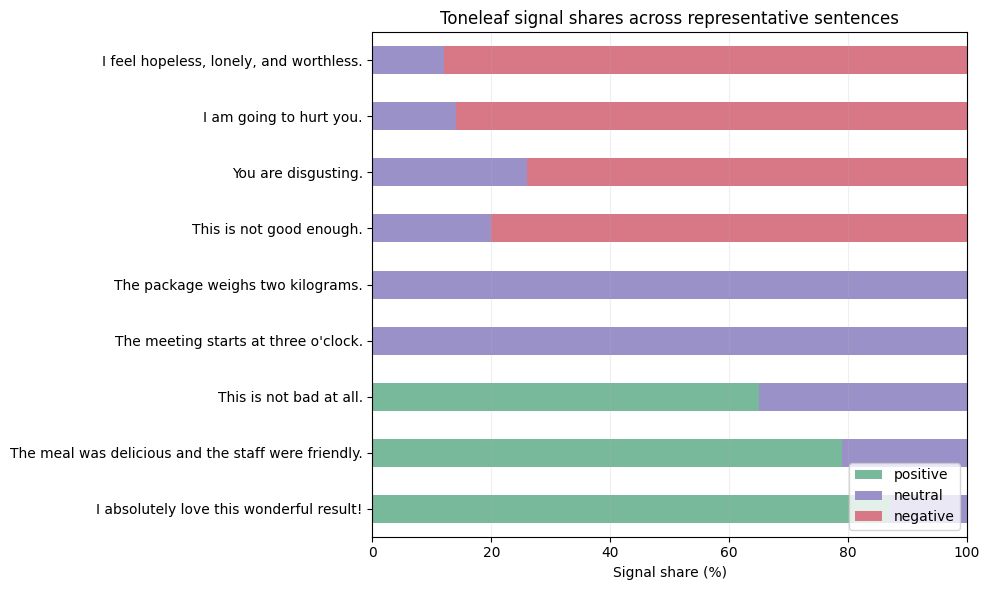

In [3]:
# Plot only the three score columns; the input text becomes the y-axis label.
ax = example_df.set_index('text')[['positive', 'neutral', 'negative']].plot(
    kind='barh', stacked=True, figsize=(10, 6),
    color=['#79b99b', '#9b91c9', '#d87886']
)
ax.set_title('Toneleaf signal shares across representative sentences')
ax.set_xlabel('Signal share (%)')
ax.set_ylabel('')
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.2)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3. Curated 53-sentence polarity evaluation

The repository includes a human-labelled smoke corpus spanning positive, neutral, negative, negated, insulting, threatening, and distress-related language. This is regression coverage, not a claim of universal model accuracy.

### Evaluation question

Does the current engine reproduce the intended positive, neutral, and negative labels in the repository's manually specified regression corpus?

### Labels and metric

For every pair `(text, expected_label)`, the engine produces a predicted label. A prediction is correct when the two labels match. Overall accuracy is defined as:

$$\text{Accuracy} = \frac{\text{number of correct predictions}}{\text{total number of labelled sentences}}$$

The displayed `confidence` is the winning signal share, not statistical confidence.

### Validity boundary

This is a **curated regression evaluation**, not an independent test set sampled from real users. It can detect code regressions and confirm documented behaviors, but it cannot estimate population-level accuracy, demographic fairness, clinical sensitivity, or generalization to unseen language.

In [4]:
# The labelled corpus is version-controlled with the application tests.
from tests.evaluation_cases import POLARITY_CASES

# Store the target and the complete prediction trace for each sentence.
evaluation_rows = []
for text, expected in POLARITY_CASES:
    result = analyze_polarity(text)
    evaluation_rows.append({
        'text': text,
        'expected': expected,
        'predicted': result['label'],
        'confidence': result['confidence'],
        'correct': result['label'] == expected,
    })
# Materialize once so all later metrics use exactly the same predictions.
evaluation_df = pd.DataFrame(evaluation_rows)
accuracy = evaluation_df['correct'].mean()

# Report both an auditable count and its normalized percentage.
print(f'Correct: {evaluation_df["correct"].sum()}/{len(evaluation_df)}')
print(f'Curated-corpus accuracy: {accuracy:.1%}')
evaluation_df.head(10)

Correct: 53/53
Curated-corpus accuracy: 100.0%


,text,expected,predicted,confidence,correct
0,I absolutely love this wonderful result!,positive,positive,87,True
1,The meal was delicious and the staff were frie...,positive,positive,79,True
2,I am delighted with the excellent service.,positive,positive,73,True
3,What a pleasant and thoughtful surprise.,positive,positive,82,True
4,You did an outstanding job and I am proud of you.,positive,positive,81,True
5,Thank you for being so kind and helpful.,positive,positive,84,True
6,Everything worked perfectly and the process wa...,positive,positive,79,True
7,"I feel grateful, hopeful, and supported.",positive,positive,78,True
8,This is not bad at all.,positive,positive,65,True
9,I do not hate the new design.,positive,positive,73,True


### Confusion matrix: locating the types of error

Accuracy compresses all decisions into one number. A confusion matrix preserves the direction of mistakes. Rows are expected labels and columns are predicted labels. Values on the main diagonal are correct; off-diagonal values reveal specific confusions such as negative text being treated as neutral.

The explicit label order prevents a missing class from silently changing the table's shape. This matters in small evaluation sets, where a model might never predict one class.

In [5]:
# Cross-tabulate expected targets against model decisions.
confusion = pd.crosstab(
    evaluation_df['expected'], evaluation_df['predicted'],
    rownames=['Expected'], colnames=['Predicted'], dropna=False,
).reindex(
    index=['positive', 'neutral', 'negative'],
    columns=['positive', 'neutral', 'negative'],
    fill_value=0,
)
confusion

Predicted,positive,neutral,negative
Expected,,,
positive,12,0,0
neutral,0,15,0
negative,0,0,26


### Class-level performance and score strength

Class-specific summaries prevent a majority class from dominating the headline metric. For each expected class, the next block reports sample count, correct count, mean winning signal share, and within-class accuracy.

`mean_confidence` must be interpreted cautiously: it summarizes how decisive the deterministic scorer was on these examples. It is not a calibrated probability and cannot be compared to a confidence interval. Because this corpus is intentionally imbalanced (more negative edge cases are included), both sample counts and class-wise results should be read alongside overall accuracy.

In [6]:
# Aggregate diagnostics by the human-specified target class.
class_summary = evaluation_df.groupby('expected').agg(
    sentences=('text', 'size'),
    correct=('correct', 'sum'),
    mean_confidence=('confidence', 'mean'),
).reindex(['positive', 'neutral', 'negative'])
# Compute within-class accuracy instead of reusing the global denominator.
class_summary['accuracy'] = class_summary['correct'] / class_summary['sentences']
class_summary

,sentences,correct,mean_confidence,accuracy
expected,,,,
positive,12,12,76.833333,1.0
neutral,15,15,100.000000,1.0
negative,26,26,82.653846,1.0


## 4. Distress-language screening

Polarity and distress are intentionally separated. A sentence can be negative without indicating self-directed distress (for example, an insult or an outward-directed threat), while a distress phrase may require special attention even when generic sentiment vocabulary is sparse.

### Task definition

The screen returns `supportive` or `distress` according to explicit self-directed, hopelessness, method, and intent patterns. The score begins with a small baseline, accumulates weighted phrase evidence, and receives a limited supplement from strongly negative polarity. The displayed distress share is capped at 96. Conceptually:

$$\text{distress share} = \min(96, \operatorname{round}(5 + 9 \times \text{weighted evidence}))$$

The implementation labels a text `distress` at a share of 50 or above. These weights and the threshold are product rules—not clinically calibrated cut-offs.

> A `supportive` result means **no strong configured distress pattern was detected**; it does not guarantee safety. A `distress` result means **the text matched configured screening patterns**; it does not establish intent, immediacy, or a mental-health condition.

In [7]:
# Contrast explicit distress, ambiguous negativity, factual mentions, and
# outward-directed harm to test the task boundary qualitatively.
distress_examples = [
    'I feel calm and supported today.',
    "The meeting starts at three o'clock.",
    'I feel hopeless and want to die.',
    'I cannot go on and I want to end my life.',
    'I feel trapped, worthless, and completely alone.',
    'I will jump from the building and hit myself.',
    'I will eat rat poison.',
    'I am a complete loser.',
    'I will run away from my family.',
    'How to tie a knot to be hanged.',
    'I will lay down on a railway track so that a train rams over me.',
    'The rat poison is stored in a locked cabinet.',
    'Hello kill me.',
    'I will kill you.',
]

# Apply the dedicated distress analyzer rather than inferring risk directly
# from the polarity label.
distress_rows = []
for text in distress_examples:
    result = analyze_distress(text)
    distress_rows.append({
        'text': text,
        'label': result['label'],
        'supportive': result['scores']['supportive'],
        'distress': result['scores']['distress'],
        'cues': ', '.join(result['cues']) or 'none',
    })
# Keep both sides of the binary share so the result remains auditable.
distress_df = pd.DataFrame(distress_rows)
distress_df

,text,label,supportive,distress,cues
0,I feel calm and supported today.,supportive,95,5,none
1,The meeting starts at three o'clock.,supportive,95,5,none
2,I feel hopeless and want to die.,distress,4,96,"want to die, hopeless"
3,I cannot go on and I want to end my life.,distress,4,96,"end my life, cannot go on"
4,"I feel trapped, worthless, and completely alone.",distress,6,94,"worthless, trapped, alone"
5,I will jump from the building and hit myself.,distress,4,96,"jump from the building, hit myself"
6,I will eat rat poison.,distress,17,83,eat rat poison
7,I am a complete loser.,distress,25,75,i am a complete loser
8,I will run away from my family.,distress,27,73,i will run away from my family
9,How to tie a knot to be hanged.,distress,17,83,how to tie a knot to be hanged


### Interpretation and boundary checks

The most important comparisons are contextual rather than numerical:

- Explicit self-directed method or intent phrases should cross the configured threshold and expose the matching phrase in `cues`.
- `The rat poison is stored in a locked cabinet` is a factual safety statement. Mentioning a hazardous object alone should not create a distress label.
- `I will kill you` is an outward-directed threat. It is strongly negative in polarity mode but should not automatically be interpreted as self-directed distress. A separate threat-detection/moderation workflow would be appropriate for that use case.
- Self-denigration and running-away language are treated as concerning screening signals in the configured rule set, even without an explicit method phrase.

These cases demonstrate intended rule boundaries, not clinical sensitivity or specificity. In a real safety workflow, uncertain context should be reviewed by a trained person, and immediate-danger situations should be directed to local emergency or crisis services rather than decided by software.

## 5. Comprehensive 745-case regression audit

A handful of examples cannot protect a language system from regressions across many interacting rules. Toneleaf therefore includes a larger deterministic audit matrix generated from version-controlled templates and cases.

### Coverage design

| Mode | Cases | Primary coverage |
|---|---:|---|
| Polarity | 464 | Positive/negative vocabulary, neutral controls, negation, intensifiers, insults, threats, and mixed phrasing |
| Distress | 281 | Methods, self-directed intent, spelling/wording variants, contextual mentions, outward-directed threats, and false-positive controls |
| Combined | 745 | Full deterministic regression contract |

For each case, the audit compares the current label with the expected label encoded in the repository. This offers broad implementation coverage and makes behavior changes visible during development.

### What this audit does not prove

The cases are designed around supported behavior and are not independent observations. Therefore, 100% audit accuracy means **conformance to the current regression specification**, not perfect real-world NLP accuracy. It does not measure generalization, prevalence-weighted performance, calibration, fairness, or clinical validity.

In [8]:
# Load the complete, version-controlled regression matrices.
from tests.comprehensive_cases import DISTRESS_AUDIT_CASES, POLARITY_AUDIT_CASES

# Evaluate each task independently so a failure cannot be hidden by the other.
audit_rows = []
for mode, cases, analyzer in [
    ('polarity', POLARITY_AUDIT_CASES, analyze_polarity),
    ('distress', DISTRESS_AUDIT_CASES, analyze_distress),
]:
    # Boolean values sum naturally: True=1 and False=0.
    correct = sum(analyzer(text)['label'] == expected for text, expected in cases)
    audit_rows.append({'mode': mode, 'correct': correct, 'total': len(cases), 'accuracy': correct / len(cases)})
# Add a combined row for a concise release-readiness check.
audit_rows.append({
    'mode': 'combined',
    'correct': sum(row['correct'] for row in audit_rows),
    'total': sum(row['total'] for row in audit_rows),
    'accuracy': sum(row['correct'] for row in audit_rows) / sum(row['total'] for row in audit_rows),
})
audit_summary = pd.DataFrame(audit_rows)
audit_summary

,mode,correct,total,accuracy
0,polarity,464,464,1.0
1,distress,281,281,1.0
2,combined,745,745,1.0


### Interpreting the audit result

A fully correct table indicates that the executed engine satisfies all 745 encoded expectations in this repository version. This is strong evidence that the implementation is internally consistent and that previously repaired edge cases remain covered.

It is deliberately **not** reported as `the model is 100% accurate`. A defensible real-world performance claim would require a separately collected, representative, deduplicated, and blinded test set with annotation guidance, inter-annotator agreement, subgroup analysis, uncertainty intervals, and an error taxonomy.

## 6. Expert interpretation, privacy, and limitations

### What the evidence supports

The fallback engine is deterministic, fast, auditable, and effective at the explicitly configured vocabulary and phrase patterns. It handles common negation, intensification, direct insults, threats, several self-directed distress constructions, and contextual false-positive controls. Cue traces make many predictions inspectable, and the regression suites make changes testable.

### What the evidence does not support

Neither the 53-sentence corpus nor the 745-case audit is an independent population sample. These results do not justify claims of universal accuracy, probability calibration, clinical validity, demographic fairness, or robustness across languages and domains.

### Known failure modes

- **Sarcasm and irony:** literal positive words can express criticism.
- **Coded or obfuscated language:** euphemisms, novel slang, and adversarial spelling may evade configured patterns.
- **Pragmatics and quotation:** a user may quote, deny, report, or discuss harmful language rather than endorse it.
- **Long context:** sentence-level rules may miss meaning established earlier in a conversation.
- **Cultural and multilingual variation:** the current English-focused lexicon cannot be assumed to transfer across communities or languages.
- **Score calibration:** signal shares express rule evidence and are not probabilities or uncertainty estimates.
- **Distribution shift:** language evolves, so static vocabulary requires monitoring and versioned updates.

### Privacy threat model

| Execution mode | Where inference occurs | Network exposure | Storage behavior in this notebook | Privacy implication |
|---|---|---|---|---|
| Local notebook / local backend | User's machine | None required for analysis | Inputs remain in memory unless the user saves notebook outputs | Strongest boundary; protect the device and notebook file |
| Hosted deployment | Operator-controlled server | Text travels over HTTPS | Application is designed for transient processing; operator logs/configuration still matter | User must trust the host and its operational controls |
| Optional offline transformer | Same machine as configured model files | No runtime model download required | Depends on local execution and notebook saving | Model path and files remain operator-controlled |

Executing this notebook saves its example text and rendered outputs inside the `.ipynb` file. Users should not paste private real-world text into a notebook they plan to commit or share. For sensitive analysis, clear outputs and review the file before distribution.

### Responsible-use boundary

Toneleaf should never be the sole basis for clinical, emergency, employment, education, insurance, legal, law-enforcement, or content-enforcement decisions. Distress screening should support careful human review, not automated punishment or diagnosis. If a person may be in immediate danger, contact local emergency services or a trusted crisis service; do not rely on a sentiment score.

### Recommended next research steps

1. Build a separately held-out, consented, and de-identified evaluation set with clear annotation guidelines.
2. Measure annotator agreement and adjudicate ambiguous cases instead of treating every label as objective ground truth.
3. Report precision, recall, F1, false-negative rate, false-positive rate, and uncertainty intervals—especially for distress screening.
4. Perform subgroup and dialectal error analysis with appropriate governance and community input.
5. Add multilingual evaluation rather than translating the English lexicon and assuming equivalence.
6. Test misspellings, spacing, Unicode confusables, quoted text, negated intent, sarcasm, and multi-turn context adversarially.
7. Version the rule set and document threshold changes so results remain reproducible.
8. If a learned model is introduced, create a model card and evaluate calibration, drift, privacy, and explainability separately.

### Reproducibility checklist

- Record the printed project root and engine identifier.
- Run all cells from top to bottom in a clean Python 3.12 environment.
- Confirm that every code cell executes without an error.
- Run `python -m unittest discover -s tests` from the repository root.
- Run `python scripts/run_comprehensive_audit.py` and compare its totals with this notebook.
- Re-run the notebook after any engine or evaluation-case change so embedded outputs are not stale.

### Conclusion

Toneleaf demonstrates a transparent, privacy-conscious baseline for local language analysis. Its strongest evidence is **engineering reliability within a clearly defined rule set**. Its responsible interpretation is correspondingly narrow: the outputs summarize configured linguistic signals, while human meaning, safety, and mental health remain context-dependent judgments that this notebook cannot determine.